In [ ]:
from nsp_solver import NurseScheduling
from experiment import test_cases, run_experiment
import os, csv

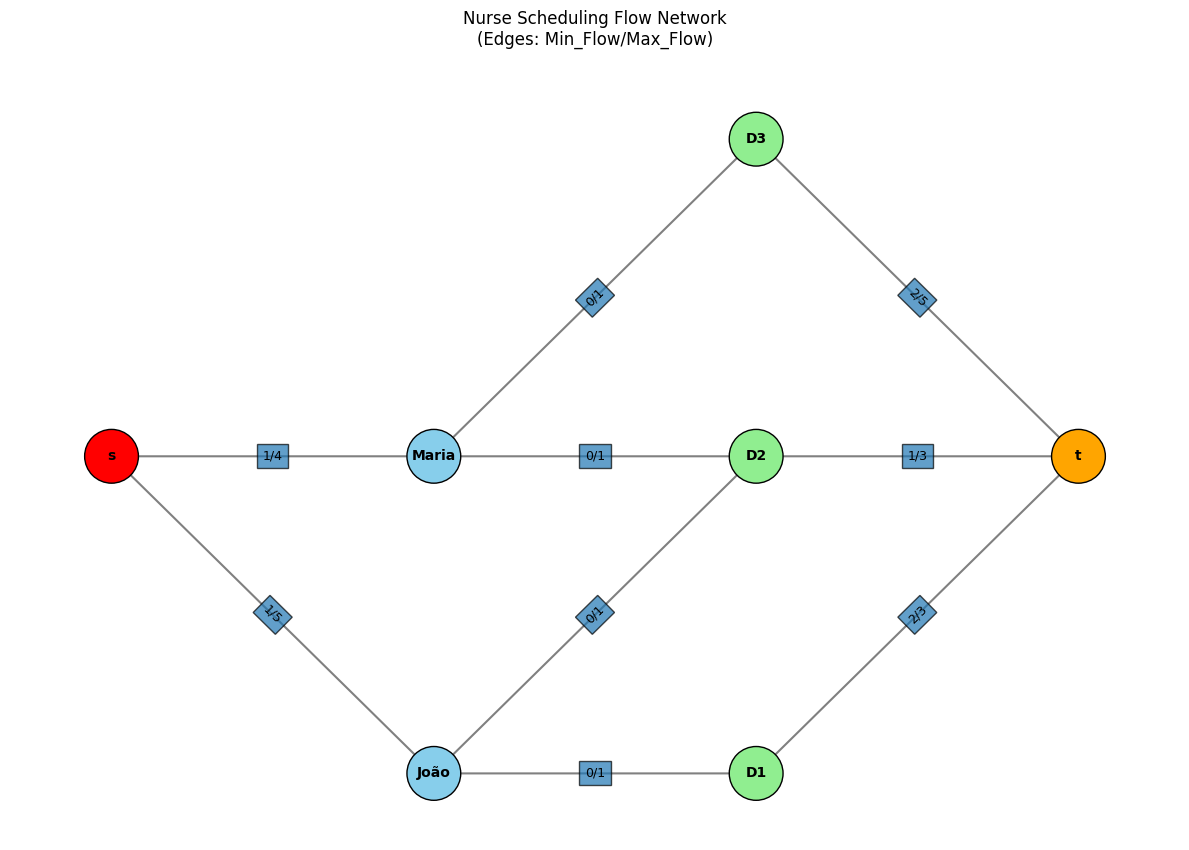

Unable to satisfy all constraints:
- All nurses must work their minimum shifts
- All shifts must have minimum staffing


In [2]:
scheduler = NurseScheduling(
    nurses=["João", "Maria"],
    shifts=["D1", "D2", "D3"],
    edges=[("João", "D1"), ("João", "D2"), ("Maria", "D2"), ("Maria", "D3")],
    nurse_limits=[(1,5), (1,4)],
    shift_limits=[(2,3), (1,3), (2,5)]
)

scheduler.show()
scheduler.run()

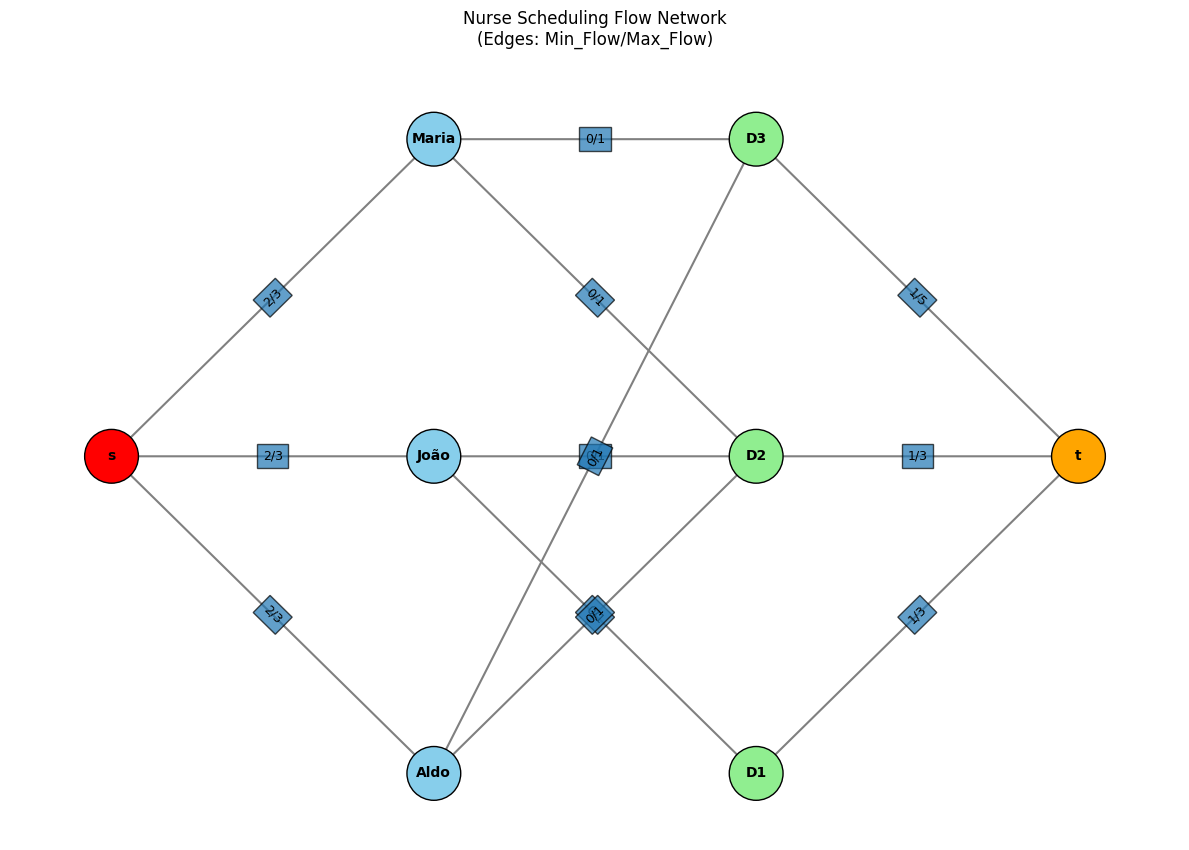


--- Scheduling Results ---
Total shifts assigned: 6

Nurse Assignments:
- Aldo: D2, D3
- João: D1, D2
- Maria: D2, D3


{'total_alocated': 6,
 'assignments': {'João': {'D1': 1, 'D2': 1},
  'Maria': {'D2': 1, 'D3': 1},
  'Aldo': {'D2': 1, 'D3': 1},
  'D1': {'t': 1},
  'D2': {'t': 3},
  'D3': {'t': 2},
  's': {'João': 2, 'Maria': 2, 'Aldo': 2},
  't': {}}}

In [3]:
scheduler = NurseScheduling(
    nurses=["João", "Maria", "Aldo"],
    shifts=["D1", "D2", "D3"],
    edges=[("João", "D1"), ("João", "D2"), ("Maria", "D2"), ("Maria", "D3"), ("Aldo", "D2"), ("Aldo", "D3")],
    nurse_limits=[(2,3), (2,3), (2,3)],
    shift_limits=[(1,3), (1,3), (1,5)]
)

scheduler.show()
scheduler.run()

In [4]:
# Choices = 6 for running ALL test cases
choice = 6

results_dir = 'experiments'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

logs = []
with open(os.path.join(results_dir, 'experiment_results.csv'), 'w', newline='') as f_csv:
    writer = csv.writer(f_csv)
    writer.writerow(["test_desc", "num_nurses", "num_shifts", "num_edges", "status", "total_Assigned", "execution_Time_s"])

    if choice in test_cases:
        test_name, params = test_cases[choice]
        result_row, log_text = run_experiment(test_name, params)
        writer.writerow(result_row)
        logs.append(f"--- {test_name} ---\n{log_text.strip()}\n")
    elif choice == 6:
        print("\nExecuting ALL tests\n")
        for key, (name, params) in test_cases.items():
            result_row, log_text = run_experiment(name, params)
            if result_row and all(val not in (None, '') for val in result_row):
                writer.writerow(result_row)
                logs.append(f"--- {name} ---\n{log_text.strip()}\n")


with open(os.path.join(results_dir, 'logs.txt'), 'w') as f_logs:
    f_logs.write("\n\n".join(logs))

print(f"\nExperiments completed! Results saved in {results_dir}/")



Executing ALL tests

Running test: small_feasible
Running test: small_infeasible
Running test: medium_complex
Running test: large_infeasible
Running test: large_feasible

Experiments completed! Results saved in experiments/
